In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../"))

from desc import set_device
set_device("gpu")

In [2]:
import numpy as np
np.set_printoptions(linewidth=np.inf, precision=4, suppress=True, threshold=sys.maxsize)
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.graph_objects as go

In [3]:
import desc

from desc.basis import *
from desc.backend import *
from desc.compute import *
from desc.coils import *
from desc.equilibrium import *
from desc.examples import *
from desc.grid import *
from desc.geometry import *
from desc.io import *

from desc.objectives import *
from desc.objectives.objective_funs import *
from desc.objectives.getters import *
from desc.objectives.normalization import compute_scaling_factors
from desc.objectives.utils import *
from desc.optimize._constraint_wrappers import *

from desc.transform import Transform
from desc.plotting import *
from desc.optimize import *
from desc.perturbations import *
from desc.profiles import *
from desc.compat import *
from desc.utils import *
from desc.magnetic_fields import *
from desc.particles import *
from diffrax import *

from desc.__main__ import main
from desc.vmec_utils import vmec_boundary_subspace
from desc.input_reader import InputReader
from desc.continuation import solve_continuation_automatic
from desc.compute.data_index import register_compute_fun
from desc.optimize.utils import solve_triangular_regularized

print_backend_info()

DESC version=0.17.1.
Using JAX backend: jax version=0.6.2, jaxlib version=0.6.2, dtype=float64.
Using device: NVIDIA GeForce RTX 4080 Laptop GPU (id=0), with 11.99 GB available memory.


# About this Notebook

Try to get a rotating x-point with simple loop current for plasma.

In [4]:
eq0 = load("desc-eq-HBT_105995_06.h5")
eq0_fb = load("eq-HBT_105995_06_free_boundary.h5")
field0 = load("hbt_default_coils.h5")
eq = load("eq-HBT_105995_06_free_boundary.h5")
field = load("coils-HBT_105995_06_free_boundary.h5")

In [5]:
R0 = 0.92
B0 = 0.35

plot_grid = LinearGrid(rho=1, M=20, N=60, NFP=1, endpoint=True)
coil_grid = LinearGrid(N=30)

plot_grid = LinearGrid(rho=1, M=20, N=60, NFP=1, endpoint=True)
coil_grid = LinearGrid(N=30)
tf = ToroidalMagneticField(B0=B0, R0=R0)

In [6]:
def add_coils_to_plot(ax, fields, nplanes=6):
    fields = fields if isinstance(fields, list) else [fields]
    for field in fields:
        data = field.compute(["R", "Z", "phi"], grid=LinearGrid(zeta=nplanes))
        for i in range(nplanes):
            ax.flat[i].scatter(data["R"][i], data["Z"][i], marker="*")
    return ax

def get_umbilic_coil(I, rmaj=0.99, rmin=0.2, helical_offset=0):
    zeta = np.linspace(0, 2 * np.pi, 41)
    R = rmaj + rmin * np.cos(zeta - helical_offset)
    Z = rmin * np.sin(zeta - helical_offset)

    data = jnp.vstack([R, zeta, Z]).T
    umbilic_coil = FourierRZCoil.from_values(
        current=I,
        coords=data,
        N=1,
        basis="rpz",
    )
    return umbilic_coil


def get_poincare_plot(
    field,
    r0,
    z0,
    ntransit=200,
    phi=6,
    bounds_R=(0, np.inf),
    bounds_Z=(-np.inf, np.inf),
    atol=1e-6,
    rtol=1e-6,
    min_step_size=1e-8,
    max_steps=10000,
    return_data=False,
):
    return poincare_plot(
        field,
        R0=r0,
        Z0=z0,
        ntransit=ntransit,
        phi=phi,
        size=0.5,
        grid=coil_grid,
        bounds_R=bounds_R,
        bounds_Z=bounds_Z,
        atol=atol,
        rtol=rtol,
        min_step_size=min_step_size,
        max_steps=max_steps,
        return_data=return_data,
    )

# Tokamak

/CODES/DESC/desc/utils.py:572: UserWarning: Integration terminated early. Plotting partial results.
diffrax message: The maximum number of solver steps was reached. Try increasing `max_steps`.
  warnings.warn(msg, err)
/tmp/ipykernel_78056/3555462809.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


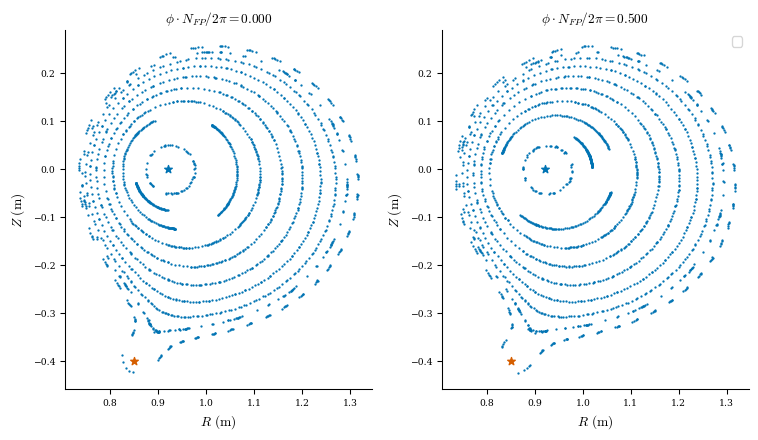

In [41]:
plasma_coil = FourierRZCoil(current=14000, R_n=R0, Z_n=0)
div_coil = FourierRZCoil(current=3000, R_n=0.85, Z_n=-0.4)
full_coils2 = SumMagneticField([plasma_coil, div_coil, tf])
fig, ax = get_poincare_plot(
    full_coils2, r0=R0 * np.ones(10), z0=-np.linspace(0.05, 0.375, 10), phi=2, ntransit=200
)
add_coils_to_plot(ax, [plasma_coil, div_coil], nplanes=2)
plt.legend()

# Single Umbilic Coil Same Direction

/CODES/DESC/desc/utils.py:572: UserWarning: Integration terminated early. Plotting partial results.
diffrax message: The maximum number of solver steps was reached. Try increasing `max_steps`.
  warnings.warn(msg, err)


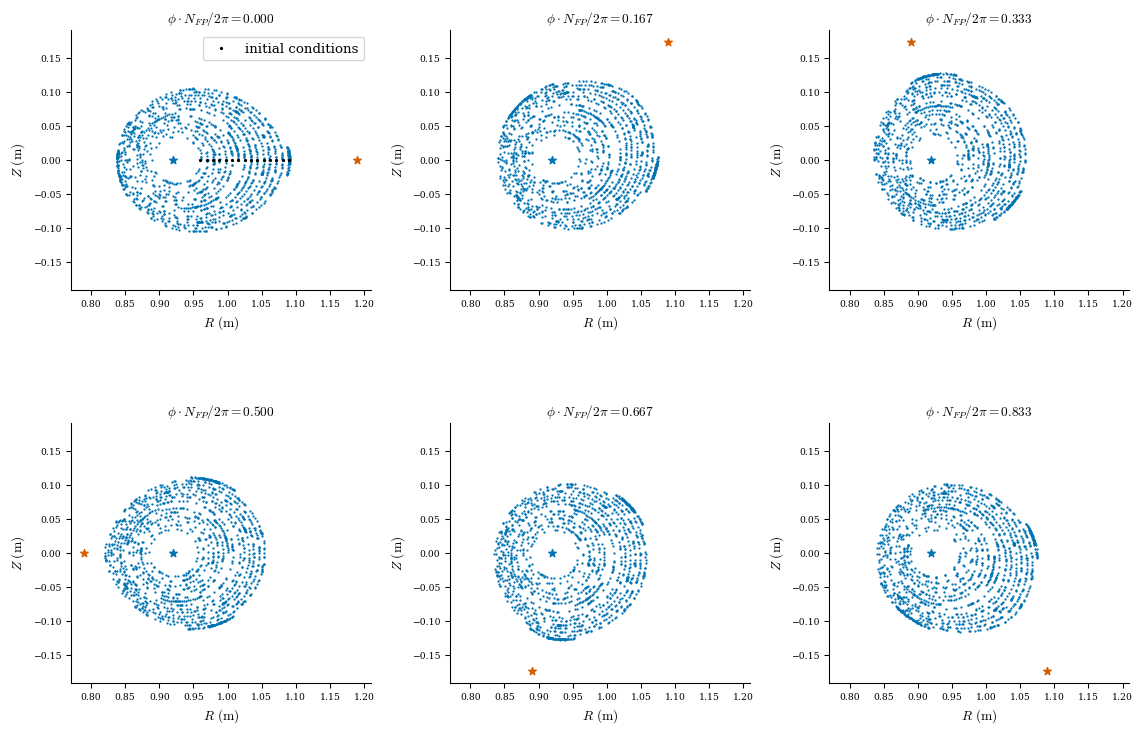

In [22]:
rmaj = 0.99
rmin = 0.2
umbilic_coil = get_umbilic_coil(I=5000, rmaj=rmaj, rmin=rmin)

plasma_coil = FourierRZCoil(current=14000, R_n=R0, Z_n=0)
full_coils3 = SumMagneticField([plasma_coil, umbilic_coil, tf])
xd = (rmaj + rmin - R0) * umbilic_coil.current / plasma_coil.current * 1
xd = 0.1

N = 15
R0is = np.linspace(rmaj - 0.03, rmaj + rmin - xd, N)
Z0is = np.zeros(N)

fig, ax = get_poincare_plot(
    full_coils3,
    r0=R0is,
    z0=Z0is,
    ntransit=200,
    bounds_R=(rmaj - rmin, rmaj + rmin),
    bounds_Z=(-rmin, rmin),
)
add_coils_to_plot(ax, [plasma_coil, umbilic_coil])
ax.flat[0].scatter(R0is, Z0is, color="black", label="initial conditions", s=2)
ax.flat[0].legend()

# Two Umbilic Coils Same Direction

/tmp/ipykernel_5225/4136284243.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


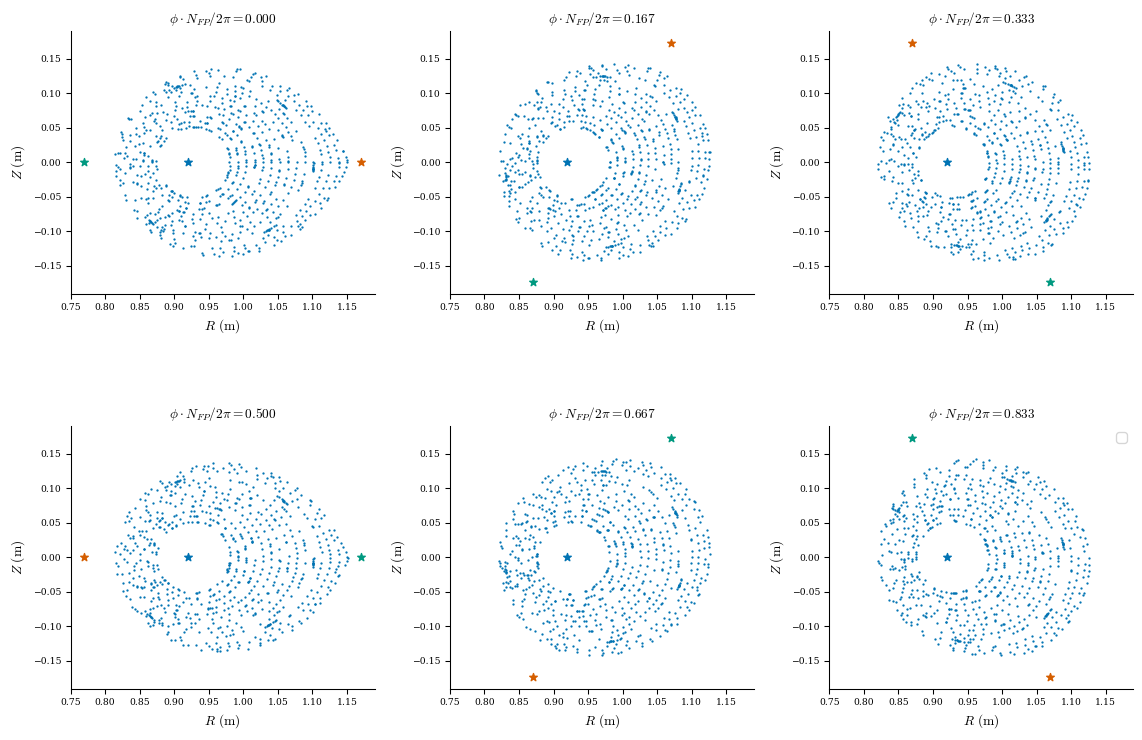

In [7]:
rmaj = 0.97
rmin = 0.2
umbilic_coil = get_umbilic_coil(I=3000, rmaj=rmaj, rmin=rmin)
umbilic_coil2 = get_umbilic_coil(I=3000, rmaj=rmaj, rmin=rmin, helical_offset=np.pi)

plasma_coil = FourierRZCoil(current=14000, R_n=R0, Z_n=0)
tf = ToroidalMagneticField(B0=B0, R0=R0)
full_coils3 = SumMagneticField([plasma_coil, umbilic_coil, umbilic_coil2, tf])
xd = (rmaj + rmin - R0) * umbilic_coil.current / plasma_coil.current * 0.4
xd = 0.02

N = 15
R0is = np.linspace(rmaj + 0.01, rmaj + rmin - xd, N)
Z0is=np.zeros(N)
fig, ax = get_poincare_plot(
    full_coils3,
    r0=R0is,
    z0=Z0is,
    ntransit=50,
    bounds_R=(rmaj - rmin, rmaj + rmin),
    bounds_Z=(-rmin, rmin),
)
add_coils_to_plot(ax, [plasma_coil, umbilic_coil, umbilic_coil2])
plt.legend()

# Compute Iota from field lines

/CODES/DESC/desc/utils.py:572: UserWarning: Integration terminated early. Plotting partial results.
diffrax message: The maximum number of solver steps was reached. Try increasing `max_steps`.
  warnings.warn(msg, err)


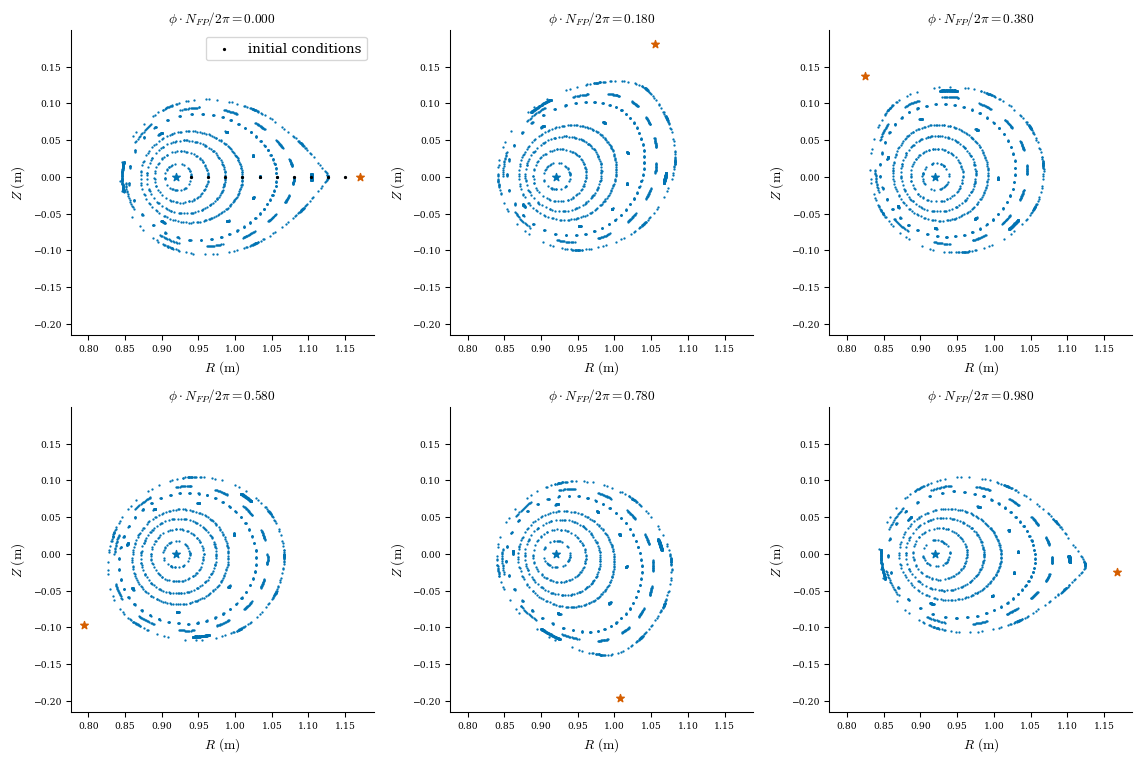

In [8]:
rmaj = 0.97
rmin = 0.2
umbilic_coil = get_umbilic_coil(I=7000, rmaj=rmaj, rmin=rmin)

plasma_coil = FourierRZCoil(current=14000, R_n=R0, Z_n=0)
tf = ToroidalMagneticField(B0=B0, R0=R0)
field = SumMagneticField([plasma_coil, umbilic_coil, tf])
xd = 0.02

N = 10
R0is = jnp.linspace(rmaj - 0.03, rmaj + rmin - xd, N)
Z0is = jnp.zeros(N)
ntransit = 200
Nphi = 50
phi = jnp.linspace(0, 2 * jnp.pi, Nphi, endpoint=False)
phis = (phi + jnp.arange(0, ntransit)[:, None] * 2 * jnp.pi).flatten()
fig, ax, data = get_poincare_plot(
    field,
    R0is,
    Z0is,
    ntransit,
    phi=Nphi,
    bounds_R=(rmaj - rmin, rmaj + rmin),
    bounds_Z=(-rmin, rmin),
    return_data=True,
    max_steps=50000,
    atol=1e-8,
    rtol=1e-8,
)
add_coils_to_plot(ax, [plasma_coil, umbilic_coil], nplanes=Nphi)
ax.flat[0].scatter(R0is, Z0is, color="black", label="initial conditions", s=2)
ax.flat[0].legend()

# above plot has many phi cuts to compute iota accurately, delete some of
# them for easy read
indices = np.linspace(0, Nphi - 1, 6, dtype=int)
keep_axes = [ax.flat[i] for i in indices]

for a in ax.flat:
    if a not in keep_axes:
        a.remove()

new_gs = plt.GridSpec(2, 3, figure=fig)
for i, a in enumerate(keep_axes):
    a.set_subplotspec(new_gs[i])

fig.set_size_inches(12, 8)
fig.tight_layout()

/CODES/DESC/desc/utils.py:572: UserWarning: Integration terminated early. Plotting partial results.
diffrax message: The maximum number of solver steps was reached. Try increasing `max_steps`.
  warnings.warn(msg, err)


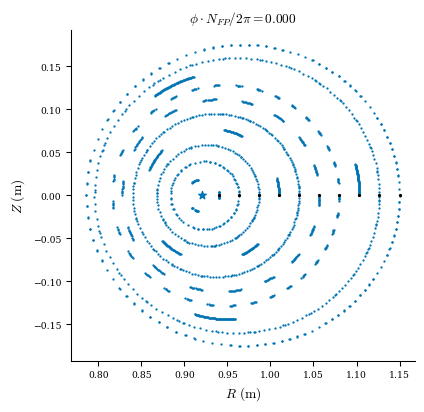

In [9]:
field_just_plasma = SumMagneticField([plasma_coil, tf])
fig, ax, data_plasma = get_poincare_plot(
    field_just_plasma,
    R0is,
    Z0is,
    ntransit,
    phi=Nphi,
    bounds_R=(rmaj - rmin, rmaj + rmin),
    bounds_Z=(-rmin, rmin),
    return_data=True,
    max_steps=50000,
    atol=1e-8,
    rtol=1e-8,
)
add_coils_to_plot(ax, [plasma_coil], nplanes=Nphi)
ax.flat[0].scatter(R0is, Z0is, color="black", label="initial conditions", s=2)
keep_axes = [ax.flat[0]]

for a in ax.flat:
    if a not in keep_axes:
        a.remove()

new_gs = plt.GridSpec(2, 3, figure=fig)
for i, a in enumerate(keep_axes):
    a.set_subplotspec(new_gs[i])

fig.set_size_inches(12, 8)
fig.tight_layout()

In [10]:
zs = data["Z"].reshape((ntransit * Nphi, -1))
rs = data["R"].reshape((ntransit * Nphi, -1))
axis_R = R0
axis_Z = 0
iotas = []
for i in range(N):
    r_traj_1 = rs[:, i]
    z_traj_1 = zs[:, i]
    R = jnp.sqrt((r_traj_1 - axis_R) ** 2 + (z_traj_1 - axis_Z) ** 2)
    # unwrap arctan2 so theta accumulates beyond +/-pi
    theta_raw = jnp.arctan2(z_traj_1 - axis_Z, r_traj_1 - axis_R)
    theta_unwrapped = jnp.unwrap(theta_raw)
    valid = ~jnp.isnan(theta_unwrapped)
    last_valid_idx = jnp.where(valid, jnp.arange(len(theta_unwrapped)), 0).max()
    total_poloidal = theta_unwrapped[last_valid_idx] - theta_unwrapped[0]
    total_toroidal = phis[last_valid_idx] - phis[0]
    iota = total_poloidal / total_toroidal
    # if integration terminated very early, do not consider that result
    if total_toroidal < ntransit / 10 * 2 * jnp.pi:
        iota = jnp.nan
    iotas.append(iota)
iotas = jnp.array(iotas)

zs = data_plasma["Z"].reshape((ntransit * Nphi, -1))
rs = data_plasma["R"].reshape((ntransit * Nphi, -1))
iotas_just_plasma = []
for i in range(N):
    r_traj_1 = rs[:, i]
    z_traj_1 = zs[:, i]
    R = jnp.sqrt((r_traj_1 - axis_R) ** 2 + (z_traj_1 - axis_Z) ** 2)
    # unwrap arctan2 so theta accumulates beyond +/-pi
    theta_raw = jnp.arctan2(z_traj_1 - axis_Z, r_traj_1 - axis_R)
    theta_unwrapped = jnp.unwrap(theta_raw)
    valid = ~jnp.isnan(theta_unwrapped)
    last_valid_idx = jnp.where(valid, jnp.arange(len(theta_unwrapped)), 0).max()
    total_poloidal = theta_unwrapped[last_valid_idx] - theta_unwrapped[0]
    total_toroidal = phis[last_valid_idx] - phis[0]
    iota = total_poloidal / total_toroidal
    if total_toroidal < ntransit/10 * 2 * jnp.pi:
        iota = jnp.nan
    iotas_just_plasma.append(iota)
iotas_just_plasma = jnp.array(iotas_just_plasma)

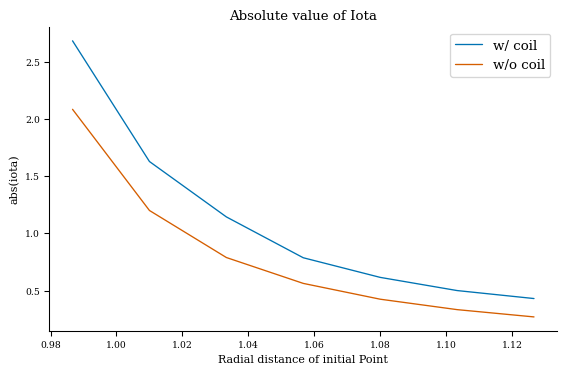

In [11]:
indices = np.arange(len(R0is))[2:-1]
plt.plot(R0is[indices], np.abs(iotas)[indices], label="w/ coil")
plt.plot(R0is[indices], np.abs(iotas_just_plasma)[indices], label="w/o coil")
plt.title("Absolute value of Iota")
plt.ylabel("abs(iota)")
plt.xlabel("Radial distance of initial Point")
plt.legend()

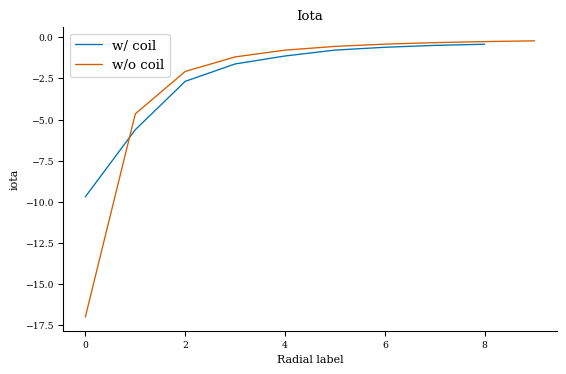

In [12]:
plt.plot(iotas, label="w/ coil")
plt.plot(iotas_just_plasma, label="w/o coil")
plt.title("Iota")
plt.ylabel("iota")
plt.xlabel("Radial label")
plt.legend()

In [13]:
R0is, iotas, iotas_just_plasma

(Array([0.94  , 0.9633, 0.9867, 1.01  , 1.0333, 1.0567, 1.08  , 1.1033, 1.1267, 1.15  ], dtype=float64),
 Array([-9.6908, -5.6213, -2.6828, -1.6279, -1.1439, -0.7868, -0.6153, -0.5001, -0.4302,     nan], dtype=float64),
 Array([-16.9858,  -4.6587,  -2.0843,  -1.2   ,  -0.7889,  -0.5626,  -0.4245,  -0.3334,  -0.2697,  -0.2236], dtype=float64))

# Iota for 2 Coil system

/CODES/DESC/desc/utils.py:572: UserWarning: Integration terminated early. Plotting partial results.
diffrax message: The maximum number of solver steps was reached. Try increasing `max_steps`.
  warnings.warn(msg, err)


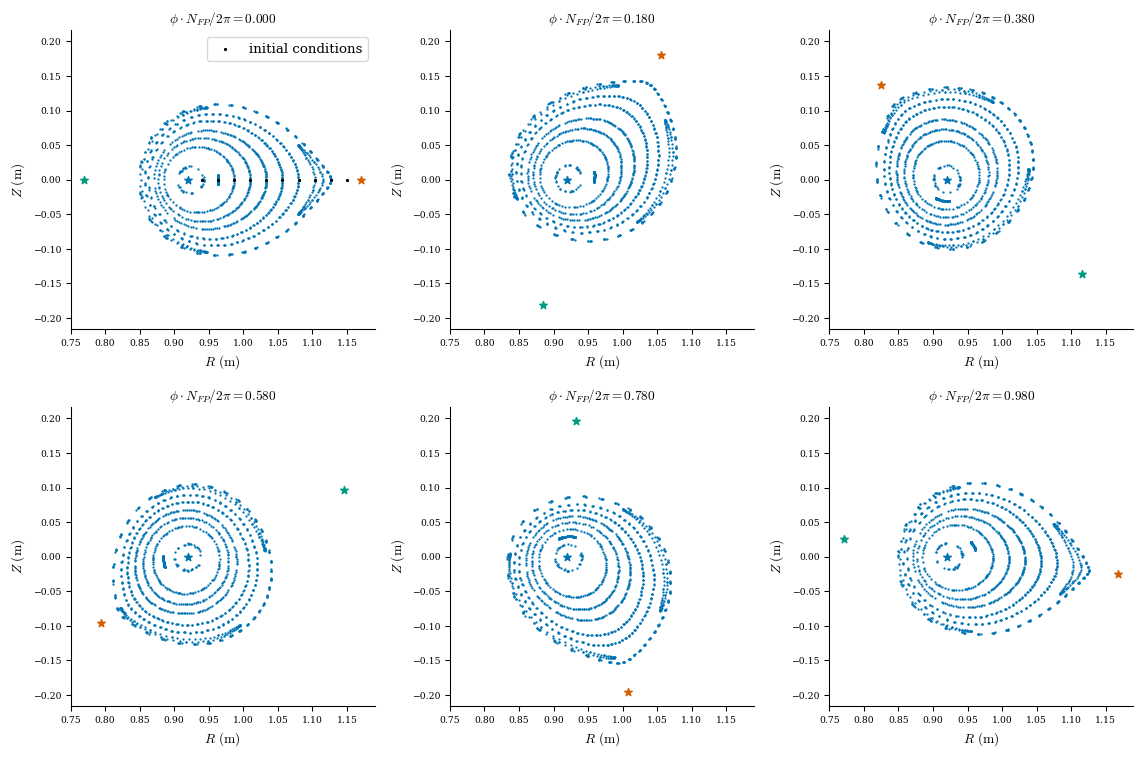

In [19]:
rmaj = 0.97
rmin = 0.2
umbilic_coil = get_umbilic_coil(I=7000, rmaj=rmaj, rmin=rmin)
umbilic_coil2 = get_umbilic_coil(I=-7000, rmaj=rmaj, rmin=rmin, helical_offset=jnp.pi)

plasma_coil = FourierRZCoil(current=14000, R_n=R0, Z_n=0)
tf = ToroidalMagneticField(B0=B0, R0=R0)
field = SumMagneticField([plasma_coil, umbilic_coil, umbilic_coil2, tf])
xd = 0.02

N = 10
R0is = jnp.linspace(rmaj - 0.03, rmaj + rmin - xd, N)
Z0is = jnp.zeros(N)
ntransit = 200
Nphi = 50
phi = jnp.linspace(0, 2 * jnp.pi, Nphi, endpoint=False)
phis = (phi + jnp.arange(0, ntransit)[:, None] * 2 * jnp.pi).flatten()
fig, ax, data2coil = get_poincare_plot(
    field,
    R0is,
    Z0is,
    ntransit,
    phi=Nphi,
    bounds_R=(rmaj - rmin, rmaj + rmin),
    bounds_Z=(-rmin, rmin),
    return_data=True,
    max_steps=50000,
    atol=1e-8,
    rtol=1e-8,
)
add_coils_to_plot(ax, [plasma_coil, umbilic_coil, umbilic_coil2], nplanes=Nphi)
ax.flat[0].scatter(R0is, Z0is, color="black", label="initial conditions", s=2)
ax.flat[0].legend()

# above plot has many phi cuts to compute iota accurately, delete some of
# them for easy read
indices = np.linspace(0, Nphi - 1, 6, dtype=int)
keep_axes = [ax.flat[i] for i in indices]

for a in ax.flat:
    if a not in keep_axes:
        a.remove()

new_gs = plt.GridSpec(2, 3, figure=fig)
for i, a in enumerate(keep_axes):
    a.set_subplotspec(new_gs[i])

fig.set_size_inches(12, 8)
fig.tight_layout()

In [24]:
zs = data2coil["Z"].reshape((ntransit * Nphi, -1))
rs = data2coil["R"].reshape((ntransit * Nphi, -1))
axis_R = R0
axis_Z = 0
iotas2coil = []
for i in range(N):
    r_traj_1 = rs[:, i]
    z_traj_1 = zs[:, i]
    R = jnp.sqrt((r_traj_1 - axis_R) ** 2 + (z_traj_1 - axis_Z) ** 2)
    # unwrap arctan2 so theta accumulates beyond +/-pi
    theta_raw = jnp.arctan2(z_traj_1 - axis_Z, r_traj_1 - axis_R)
    theta_unwrapped = jnp.unwrap(theta_raw)
    valid = ~jnp.isnan(theta_unwrapped)
    last_valid_idx = jnp.where(valid, jnp.arange(len(theta_unwrapped)), 0).max()
    total_poloidal = theta_unwrapped[last_valid_idx] - theta_unwrapped[0]
    total_toroidal = phis[last_valid_idx] - phis[0]
    iota = total_poloidal / total_toroidal
    # if integration terminated very early, do not consider that result
    if total_toroidal < ntransit / 10 * 2 * jnp.pi:
        iota = jnp.nan
    iotas2coil.append(iota)
iotas2coil = jnp.array(iotas2coil)

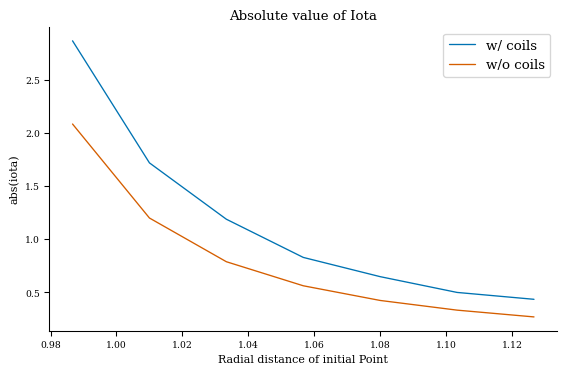

In [25]:
indices = np.arange(len(R0is))[2:-1]
plt.plot(R0is[indices], np.abs(iotas2coil)[indices], label="w/ coils")
plt.plot(R0is[indices], np.abs(iotas_just_plasma)[indices], label="w/o coils")
plt.title("Absolute value of Iota")
plt.ylabel("abs(iota)")
plt.xlabel("Radial distance of initial Point")
plt.legend()

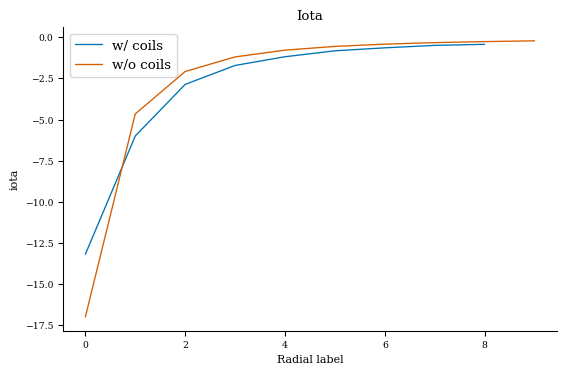

In [26]:
plt.plot(iotas2coil, label="w/ coils")
plt.plot(iotas_just_plasma, label="w/o coils")
plt.title("Iota")
plt.ylabel("iota")
plt.xlabel("Radial label")
plt.legend()

In [28]:
R0is, iotas2coil, iotas_just_plasma

(Array([0.94  , 0.9633, 0.9867, 1.01  , 1.0333, 1.0567, 1.08  , 1.1033, 1.1267, 1.15  ], dtype=float64),
 Array([-13.1818,  -6.0002,  -2.8668,  -1.7187,  -1.1887,  -0.8294,  -0.6484,  -0.5   ,  -0.4353,      nan], dtype=float64),
 Array([-16.9858,  -4.6587,  -2.0843,  -1.2   ,  -0.7889,  -0.5626,  -0.4245,  -0.3334,  -0.2697,  -0.2236], dtype=float64))

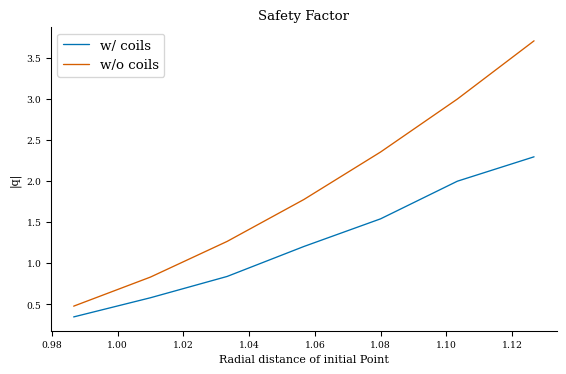

In [30]:
indices = np.arange(len(R0is))[2:-1]
plt.plot(R0is[indices], 1/np.abs(iotas2coil)[indices], label="w/ coils")
plt.plot(R0is[indices], 1/np.abs(iotas_just_plasma)[indices], label="w/o coils")
plt.title("Safety Factor")
plt.ylabel("|q|")
plt.xlabel("Radial distance of initial Point")
plt.legend()

In [35]:
a = np.vstack([iotas, iotas_just_plasma])
np.vstack([a, R0is])

array([[ -9.6908,  -5.6213,  -2.6828,  -1.6279,  -1.1439,  -0.7868,  -0.6153,  -0.5001,  -0.4302,      nan],
       [-16.9858,  -4.6587,  -2.0843,  -1.2   ,  -0.7889,  -0.5626,  -0.4245,  -0.3334,  -0.2697,  -0.2236],
       [  0.94  ,   0.9633,   0.9867,   1.01  ,   1.0333,   1.0567,   1.08  ,   1.1033,   1.1267,   1.15  ]])